In [264]:
from typing import TypedDict, List, Annotated, Optional
from langgraph.graph import StateGraph, START, END, add_messages, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, SystemMessage
import os
import json
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from IPython.display import Image, display
from db.database import SessionLocal, init_db
from db.crud import create_track, save_syllabus
import re
load_dotenv()
init_db()


In [265]:
llm=ChatGroq(model_name="Llama-3.3-70B-Versatile", api_key=os.getenv('GROQ_API'))

In [266]:
llm.invoke("what is your name").content

'I\'m an artificial intelligence model known as Llama. Llama stands for "Large Language Model Meta AI."'

In [170]:
tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))
response = tavily_client.search("tell me about mutual funds", include_answer=True)
print(response['answer'])


A mutual fund pools money from many investors to buy a diversified portfolio of stocks, bonds, or other securities managed by professionals. Investors buy shares from the fund, which can offer diversification and professional management. Mutual funds can be equity or debt-focused.


In [267]:
class SyllabusItem(BaseModel):
    day: int
    title: str
    concepts:List[str]
    
class AgentState(TypedDict):
    topic: str
    total_days: int
    syllabus: list[SyllabusItem]  # [{day, title, goal, concepts}]
    revision_count: int = 0     # tracks retry loops
    quality_score: float = 0.0,
    track_id: int

class Source(BaseModel):
    url: str = Field(description="URL of the source")
    title: str = Field(description="Title of the article")
    content: str = Field(description="Relevant extracted content from the page")
    quality_score: float = Field(
        description="Quality score between 0 and 10",
        ge=0,
        le=10
    )

class FilteredSources(BaseModel):
    filtered_sources: List[Source] = Field(
        description="Top 5 best sources for learning the topic"
    )
    
class SyllabusItem(BaseModel):
    day: int = Field(description="Day number in the syllabus")
    title: str = Field(description="Title for the day")
    concepts: List[str] = Field(
        description="2 to 4 concepts introduced on this day"
    )

class SyllabusOutput(BaseModel):
    syllabus: List[SyllabusItem]


In [268]:
def parse_input(state:AgentState)->AgentState:
    """
    Sanitise and normalise the raw inputs.
    - Strips whitespace / lowercases topic for search consistency
    - Clamps total_days between 3 and 60
    - Resets control-flow flags
    """
    cleaned_topic = state['topic'].strip()
    clamped_days  = max(3, min(60, state['total_days']))
    return {
        "topic":      cleaned_topic,
        "total_days": clamped_days
    }

In [269]:
def search_topic(state: AgentState) -> AgentState:
    """
    Fires 3 Tavily queries and stores raw results in search_results.

    search_depth="advanced" means Tavily fetches full page content,
    so each result has a `raw_content` field with the full article text —
    much richer than a basic snippet search.

    Queries:
      1. how to learn {topic} for beginners
      2. best {topic} learning roadmap
      3. {topic} core concepts fundamentals
    """
    
    topic=state['topic']
    queries = [
        f"how to learn {topic} for beginners complete guide",
        f"best {topic} learning roadmap step by step",
        f"{topic} core concepts fundamentals explained",
    ]
    all_results: list[dict]=[]
    for query in queries:
        try:
            search_result = tavily_client.search(query=query, search_depth="advanced",max_results=3,include_images=False)   
            results = search_result["results"]
            all_results.extend(results)
            print(f"[web_search] '{query}' → {len(search_result['results'])} results")
        except Exception as e:
            print(f"[web_search] Query failed: {query!r} → {e}")
    print(f"[web_search] Total: {len(all_results)} results")
    return {"search_results": all_results}

In [270]:
def filter_search_results(state: AgentState) -> dict:
    """
    Select the best learning sources from Tavily search results
    using structured output.
    """
    
    import re

    def sanitize_text(text: str) -> str:
        if not text:
            return ""
        # Remove non-ASCII / control characters
        text = text.encode("ascii", errors="ignore").decode("ascii")
        # Collapse whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text[:300]  # Truncate to avoid token bloat

    topic = state["topic"]

    results = state["search_results"][:10]

    trimmed_results = [
    {
        "url": r.get("url"),
        "title": sanitize_text(r.get("title", "")),
        "content": sanitize_text(r.get("content", "")),
    }
        for r in results
    ]

    # Use default structured output method (no method argument)
    structured_llm = llm.with_structured_output(FilteredSources)

    response: FilteredSources = structured_llm.invoke([
        SystemMessage(
            content=(
                "You are an expert research assistant that selects "
                "high-quality educational learning resources."
            )
        ),
        HumanMessage(
            content=f"""
Topic: {topic}

Below are search results.

Select the **5 best learning resources**.

Prioritize:
- tutorials
- official documentation
- structured beginner guides
- educational articles

Avoid:
- forums
- social media
- discussions

Return the selected sources with:
- url
- title
- a short relevant content excerpt
- quality score (0-10)

Search Results:
{trimmed_results}
"""
        )
    ])

    print(f"[filter_sources] Selected {len(response.filtered_sources)} sources")

    return {
        "filtered_sources": [s.model_dump() for s in response.filtered_sources]
    }


In [271]:
def generate_syllabus(state: AgentState) -> dict:
    structured_llm = llm.with_structured_output(SyllabusOutput)
    response: SyllabusOutput = structured_llm.invoke([
        SystemMessage(content="""You are an expert curriculum designer 
        specialising in beginner-friendly learning paths.
        You MUST return the response using the provided tool schema.
        The output must contain a field called `syllabus`."""),
        HumanMessage(content=f"""
Design a {state['total_days']}-day learning curriculum for: "{state['topic']}"
Target level: beginner

Rules:
1. Day 1 must explain what {state['topic']} is and why it matters
2. Each day must introduce exactly 2–4 concepts
3. Concepts must build logically from previous days
4. Day {state['total_days']} must be a capstone ("putting it all together")
5. Titles should be curiosity-driven and engaging
""")
    ])

    print(f"[generate_syllabus] Generated {len(response.syllabus)} days")
    return {"syllabus": [s.model_dump() for s in response.syllabus]}

In [272]:
def save_to_db(state: AgentState) -> dict:
    """
    Creates a Track row and saves all SyllabusItems to SQLite.
    Returns track_id so downstream systems (Graph 2) can reference it.
    """
    db = SessionLocal()
    try:
        # Create the track
        track = create_track(
            db=db,
            topic=state["topic"],
            total_days=state["total_days"],
        )

        # Save every syllabus item
        save_syllabus(
            db=db,
            track_id=track.id,
            syllabus=state["syllabus"],   # already list[dict] from model_dump()
        )

        print(f"[save_to_db] Track {track.id} saved — {len(state['syllabus'])} days")
        return {"track_id": track.id}

    except Exception as e:
        db.rollback()
        print(f"[save_to_db] Failed: {e}")
        raise
    finally:
        db.close()

In [273]:
def build_curriculum_graph():
    g = StateGraph(AgentState)

    # nodes
    g.add_node("parse_input",       parse_input)
    g.add_node("generate_syllabus", generate_syllabus)
    g.add_node("save_to_db", save_to_db)

    # edges (connections)
    g.add_edge(START, "parse_input")
    g.add_edge("parse_input", "generate_syllabus")
    g.add_edge("generate_syllabus","save_to_db")
    g.add_edge("save_to_db",END)

    # Optionally, return or use the graph
    return g.compile()


In [274]:
curriculum_graph = build_curriculum_graph()

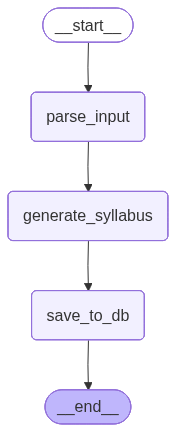

In [275]:
display(Image(curriculum_graph.get_graph().draw_mermaid_png()))

In [276]:
test_state = {
    "topic": "mutual funds",
    "total_days": 1,
    "syllabus": []}

result = curriculum_graph.invoke(test_state)
print(result)

[generate_syllabus] Generated 3 days
[save_to_db] Track 2 saved — 3 days
{'topic': 'mutual funds', 'total_days': 3, 'syllabus': [{'day': 1, 'title': 'Unlocking the Power of Mutual Funds: An Introduction', 'concepts': ['What are Mutual Funds', 'Benefits of Investing in Mutual Funds', 'Types of Mutual Funds']}, {'day': 2, 'title': 'Navigating the World of Mutual Funds: Key Concepts', 'concepts': ['How Mutual Funds are Priced', 'Diversification in Mutual Funds', 'Risk and Return in Mutual Funds']}, {'day': 3, 'title': 'Putting it all Together: Creating Your Mutual Fund Portfolio', 'concepts': ['Evaluating Mutual Fund Performance', 'Building a Diversified Mutual Fund Portfolio', 'Mutual Fund Investment Strategies']}], 'track_id': 2}


MAKING THE SECOND GRAPH

In [230]:
class DailyContentState(TypedDict):
    # inputs
    topic:            str
    total_days:       int
    track_id:         int
    syllabus_item:    dict         # {day, title, concepts}
    previous_title:   Optional[str]

    # intermediate
    search_results:   list[dict]
    filtered_sources: list[dict]
    messages:         Annotated[List[BaseMessage], add_messages]

    # outputs
    card_hook:        str
    card_body:        str
    card_practical:   str
    diagram_code:     str
    diagram_type:     str
    sources:          list[dict]   # [{title, url}] shown at bottom of card
    card_ready:       bool

In [231]:
def sanitize_text(text: str, max_chars: int = 800) -> str:
    """Remove non-ASCII / control chars, collapse whitespace, truncate."""
    if not text:
        return ""
    text = text.encode("ascii", errors="ignore").decode("ascii")
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:max_chars]

In [232]:
def search_for_content(state: DailyContentState) -> dict:
    """
    Fires concept-targeted Tavily queries for today's syllabus item.
    Queries are specific to today's concepts, not generic topic overviews.
    search_depth='advanced' returns full raw_content per result.
    """
    topic   = state["topic"]
    item    = state["syllabus_item"]
    title   = item["title"]
    concepts = item["concepts"]
    
    queries = [
        f"{topic} {title}",
        *[f"{topic} {concept} explained" for concept in concepts[:3]],
    ]
    
    all_results: list[dict] = []
    seen_urls: set[str]     = set()
    
    for query in queries:
        try:
            result = tavily_client.search(
                query=query,
                search_depth="advanced",
                max_results=4,
                include_images=False,
            )
            for r in result["results"]:
                url = r.get("url", "")
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    all_results.append(r)
            print(f"[search] '{query}' → {len(result['results'])} results")
        except Exception as e:
            print(f"[search] Query failed: {query!r} → {e}")

    print(f"[search] Total unique results: {len(all_results)}")
    return {"search_results": all_results}

In [233]:
def filter_sources(state: DailyContentState) -> dict:
    """
    LLM selects and scores the top 5 sources by relevance to today's concepts.
    """

    topic = state["topic"]
    item = state["syllabus_item"]
    results = state["search_results"][:12]

    trimmed = [
        {
            "url": r.get("url"),
            "title": sanitize_text(r.get("title", ""), 200),
            "content": sanitize_text(r.get("raw_content") or r.get("content", ""), 800),
        }
        for r in results
    ]

    structured_llm = llm.with_structured_output(FilteredSources)

    system = SystemMessage(content=(
        "You are an expert research assistant selecting high-quality "
        "educational resources for a daily learning card. "
        "Prioritise tutorials, official docs, beginner guides, and educational articles. "
        "Avoid forums, social media, and discussion threads."
    ))

    human = HumanMessage(content=f"""
Topic: {topic}
Today's lesson: "{item['title']}"
Concepts to cover: {', '.join(item['concepts'])}

Select the 5 best sources from the results below.

For each source return:
- url
- title
- content: the most relevant excerpt (max 500 words)
- relevance_score (0-10)

Search Results:
{json.dumps(trimmed, indent=2)}
""")

    response: FilteredSources = structured_llm.invoke([system, human])

    filtered = [s.model_dump() for s in response.filtered_sources]

    print(f"[filter] Selected {len(filtered)} sources")

    return {"filtered_sources": filtered}

In [ ]:
def write_card(state: DailyContentState) -> dict:
    """
    Writes the full day card from filtered source content.

    Sections:
      HOOK       — why this matters, not a definition
      BODY       — 400-600 words, all concepts, markdown formatted
      PRACTICAL  — one concrete thing to do today
      SOURCES    — 2-3 clean links
    """
    topic = state["topic"]
    item = state["syllabus_item"]
    sources = state["filtered_sources"]
    previous_title = state.get("previous_title")
    total_days = state["total_days"]
    day = item["day"]

    source_context = "\n\n---\n\n".join(
        f"Source: {s['title']}\nURL: {s['url']}\n{s['content'][:2000]}"
        for s in sources
    )

    yesterday_line = (
        f"Yesterday the reader learned about: \"{previous_title}\". "
        "Open with a single sentence that connects yesterday to today.\n"
        if previous_title
        else ""
    )

    capstone_note = (
        "\nThis is the FINAL day. End the body with a short "
        "'Where to go from here' section listing 3 directions to explore next."
        if day == total_days
        else ""
    )

    system = SystemMessage(content="""You are a writer for a daily learning newsletter.
Your style is clear, engaging, and substantive — like a smart friend explaining something they know deeply.
Use markdown: bold key terms, short paragraphs, bullet points only when genuinely listing things.
Be specific: use real examples, concrete numbers, and practical context from the sources.
Never be vague. Every sentence should earn its place.""")

    human = HumanMessage(content=f"""
Write a learning card for Day {day} of {total_days} in a course on "{topic}".

{yesterday_line}Today's lesson: "{item['title']}"
Concepts to cover: {', '.join(item['concepts'])}
{capstone_note}

Source material:
{source_context}

---

Produce exactly these four sections with these exact labels:

HOOK:
(1-2 sentences. Why does this concept matter right now? Make the reader want to continue.)

BODY:
(400-600 words. Cover all {len(item['concepts'])} concepts with real examples. Markdown formatted.)

PRACTICAL:
(One single concrete action the reader can take or observe today. Not "read more about it".)

SOURCES:
(2-3 most useful sources as: - Title | URL)
""")

    response = llm.invoke([system, human])
    raw = response.content

    # ── Parse sections ────────────────────────────────────────────────────────
    hook, body, practical, sources_raw = "", "", "", ""

    if all(s in raw for s in ["HOOK:", "BODY:", "PRACTICAL:", "SOURCES:"]):
        hook      = raw.split("HOOK:")[1].split("BODY:")[0].strip().replace("##", "").strip()
body      = raw.split("BODY:")[1].split("PRACTICAL:")[0].strip().replace("##", "").strip()
practical = raw.split("PRACTICAL:")[1].split("SOURCES:")[0].strip().replace("##", "").strip()
        sources_raw = raw.split("SOURCES:")[1].strip()
    else:
        print("[write_card] Section parsing failed — dumping to body")
        body = raw
        hook = f"Today: {item['title']}"

    # Parse sources into [{title, url}]
    parsed_sources = []
    for line in sources_raw.splitlines():
        line = line.strip().lstrip("- ").strip()
        if "|" in line:
            parts = line.split("|", 1)
            parsed_sources.append({
                "title": parts[0].strip(),
                "url":   parts[1].strip(),
            })

    return {
        "card_hook":      hook,
        "card_body":      body,
        "card_practical": practical,
        "sources":        parsed_sources,
        "card_ready":     True,
        "messages":       [human, response],
    }

In [235]:
def build_graph():
    g = StateGraph(DailyContentState)

    g.add_node("search_for_content", search_for_content)
    g.add_node("filter_sources",     filter_sources)
    g.add_node("write_card",         write_card)

    g.add_edge(START,                "search_for_content")
    g.add_edge("search_for_content", "filter_sources")
    g.add_edge("filter_sources",     "write_card")
    g.add_edge("write_card",         END)

    return g.compile()


graph = build_graph()

In [279]:
result = graph.invoke({
    
    
        "topic":            result['topic'],
        "total_days":       result['total_days'],
        "track_id":         result['track_id'],
        "syllabus_item":    result['syllabus'][0],
        "previous_title":   "",
        "search_results":   [],
        "filtered_sources": [],
        "messages":         [],
        "card_hook":        "",
        "card_body":        "",
        "card_practical":   "",
        "sources":          [],
        "card_ready":       False,
    }
)

[search] 'mutual funds Unlocking the Power of Mutual Funds: An Introduction' → 4 results
[search] 'mutual funds What are Mutual Funds explained' → 4 results
[search] 'mutual funds Benefits of Investing in Mutual Funds explained' → 4 results
[search] 'mutual funds Types of Mutual Funds explained' → 4 results
[search] Total unique results: 15
[filter] Selected 5 sources


In [280]:
print(result)

{'topic': 'mutual funds', 'total_days': 3, 'track_id': 2, 'syllabus_item': {'day': 1, 'title': 'Unlocking the Power of Mutual Funds: An Introduction', 'concepts': ['What are Mutual Funds', 'Benefits of Investing in Mutual Funds', 'Types of Mutual Funds']}, 'previous_title': '', 'search_results': [{'url': 'https://azbigmedia.com/business/unlocking-the-power-of-mutual-funds-a-beginners-guide-to-investing/', 'title': "Unlocking the power of mutual funds: A beginner's guide to investing", 'content': 'not everyone begins from the same place, and there must be measures put in place to address those imbalances. Debt can take the form of real assets, money, stocks, or the promise of payment. In corporate finance, debt is more defined as money borrowed through the issuing of bonds. Yet, index funds are a unique form of fund that follows a designated benchmark. Hence, providing a greater level of diversity within the portfolio. [...] A variety of important factors, such as a person’s appetite fo